## 1. Clean Dataset

In [1]:
import pandas as pd

df = pd.read_parquet("../data/interim/vehicles_trimmed.parquet")

# Convert types
# df["year"] = df["year"].astype("Int64")
df["year"] = pd.to_numeric(df["year"], errors="coerce").astype("int64")
df["odometer"] = df["odometer"].astype("float")
df["price"] = df["price"].astype("float")
df["posting_date"] = pd.to_datetime(
    df["posting_date"],
    errors="coerce",
    utc=True
)

# Drop rows with missing critical fields
df = df.dropna(subset=["price", "year", "odometer"])

# Clean model text
df["model"] = (
    df["model"]
    .astype(str)
    .str.lower()
    .str.replace(r"[^a-z0-9 ]", "", regex=True)
    .str.strip()
)

## 2. Add Derived Fields

In [2]:
import numpy as np

df["vehicle_age"] = df["posting_date"].dt.year - df["year"]
df["cost_per_mile"] = df["price"] / df["odometer"]
df["log_price"] = np.log(df["price"])

In [3]:
# check dataframe types
df.dtypes

price                        float64
year                           int64
manufacturer                  object
model                         object
odometer                     float64
state                         object
posting_date     datetime64[ns, UTC]
region                        object
vehicle_age                    int64
cost_per_mile                float64
log_price                    float64
dtype: object

## EDA

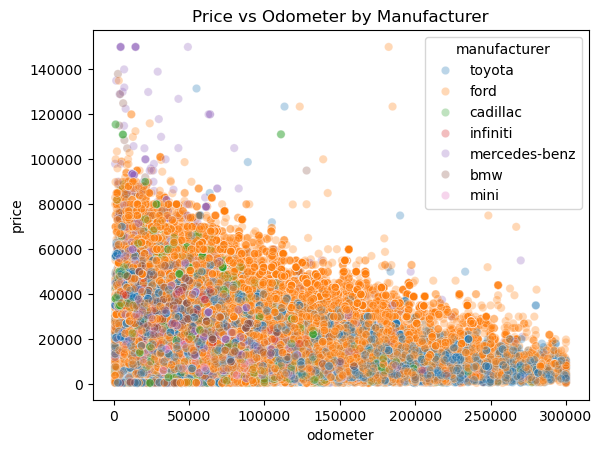

In [4]:
# Price vs. Odometer (raw depreciation curve)
import seaborn as sns
import matplotlib.pyplot as plt

sns.scatterplot(data=df, x="odometer", y="price", hue="manufacturer", alpha=0.3)
plt.title("Price vs Odometer by Manufacturer")
plt.show()

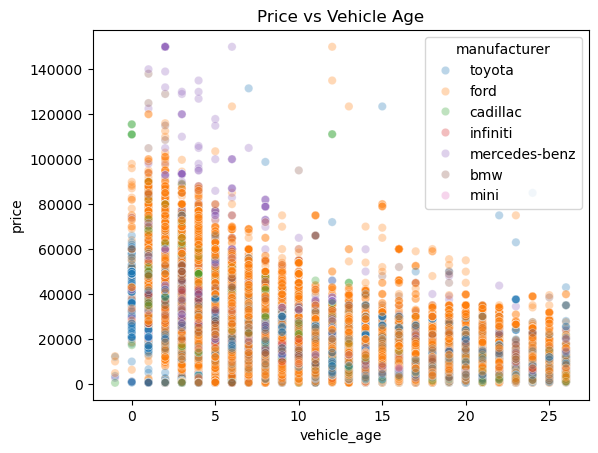

In [5]:
# Price vs Age 
sns.scatterplot(data=df, x="vehicle_age", y="price", hue="manufacturer", alpha=0.3)
plt.title("Price vs Vehicle Age")
plt.show()

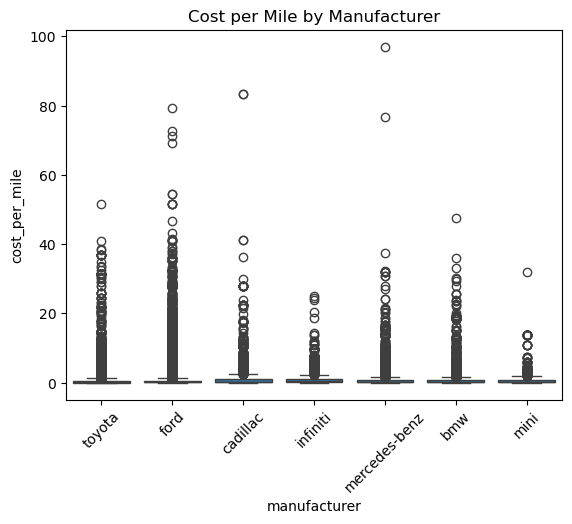

In [6]:
# Cost per mile distribution
sns.boxplot(data=df, x="manufacturer", y="cost_per_mile")
plt.xticks(rotation=45)
plt.title("Cost per Mile by Manufacturer")
plt.show()

## 4. Build depreciation curves

In [7]:
# Log-Linear Regression

import statsmodels.formula.api as smf

model = smf.ols("log_price ~ odometer + C(manufacturer)", data=df).fit()
model.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:              log_price   R-squared:                       0.352
Model:                            OLS   Adj. R-squared:                  0.352
Method:                 Least Squares   F-statistic:                     9588.
Date:                Fri, 17 Apr 2026   Prob (F-statistic):               0.00
Time:                        19:15:06   Log-Likelihood:            -1.2859e+05
No. Observations:              123451   AIC:                         2.572e+05
Df Residuals:                  123443   BIC:                         2.573e+05
Df Model:                           7                                         
Covariance Type:            nonrobust                                         
====================================================================================================
                                       coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------------------------
Intercept                           10.3597      0.006   1598.479      0.000      10.347      10.372
C(manufacturer)[T.cadillac]         -0.0248      0.011     -2.309      0.021      -0.046      -0.004
C(manufacturer)[T.ford]              0.1525      0.007     22.791      0.000       0.139       0.166
C(manufacturer)[T.infiniti]          0.0215      0.012      1.790      0.073      -0.002       0.045
C(manufacturer)[T.mercedes-benz]     0.0591      0.009      6.353      0.000       0.041       0.077
C(manufacturer)[T.mini]             -0.3712      0.016    -23.382      0.000      -0.402      -0.340
C(manufacturer)[T.toyota]           -0.0057      0.007     -0.784      0.433      -0.020       0.009
odometer                         -8.232e-06   3.25e-08   -253.671      0.000    -8.3e-06   -8.17e-06
==============================================================================
Omnibus:                    29111.493   Durbin-Watson:                   1.657
Prob(Omnibus):                  0.000   Jarque-Bera (JB):           119786.913
Skew:                          -1.117   Prob(JB):                         0.00
Kurtosis:                       7.278   Cond. No.                     1.09e+06
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[2] The condition number is large, 1.09e+06. This might indicate that there are
strong multicollinearity or other numerical problems.
"""

In [8]:
# add vehicle_age causes data conversion issues

import statsmodels.formula.api as smf

model = smf.ols(
    "log_price ~ odometer + vehicle_age + C(manufacturer)",
    data=df
).fit()

model.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:              log_price   R-squared:                       0.486
Model:                            OLS   Adj. R-squared:                  0.486
Method:                 Least Squares   F-statistic:                 1.458e+04
Date:                Fri, 17 Apr 2026   Prob (F-statistic):               0.00
Time:                        19:15:07   Log-Likelihood:            -1.1433e+05
No. Observations:              123451   AIC:                         2.287e+05
Df Residuals:                  123442   BIC:                         2.288e+05
Df Model:                           8                                         
Covariance Type:            nonrobust                                         
====================================================================================================
                                       coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------------------------
Intercept                           10.6252      0.006   1782.436      0.000      10.614      10.637
C(manufacturer)[T.cadillac]         -0.0454      0.010     -4.746      0.000      -0.064      -0.027
C(manufacturer)[T.ford]              0.0749      0.006     12.535      0.000       0.063       0.087
C(manufacturer)[T.infiniti]         -0.0471      0.011     -4.402      0.000      -0.068      -0.026
C(manufacturer)[T.mercedes-benz]     0.1020      0.008     12.308      0.000       0.086       0.118
C(manufacturer)[T.mini]             -0.3595      0.014    -25.415      0.000      -0.387      -0.332
C(manufacturer)[T.toyota]           -0.0435      0.006     -6.707      0.000      -0.056      -0.031
odometer                         -3.631e-06   3.87e-08    -93.897      0.000   -3.71e-06   -3.56e-06
vehicle_age                         -0.0760      0.000   -179.133      0.000      -0.077      -0.075
==============================================================================
Omnibus:                    40631.548   Durbin-Watson:                   1.663
Prob(Omnibus):                  0.000   Jarque-Bera (JB):           318536.983
Skew:                          -1.370   Prob(JB):                         0.00
Kurtosis:                      10.377   Cond. No.                     1.09e+06
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[2] The condition number is large, 1.09e+06. This might indicate that there are
strong multicollinearity or other numerical problems.
"""

## 5. Optimal replacement mileage

In [ ]:
df_sorted = df.sort_values("odometer")
df_sorted["rolling_cpm"] = df_sorted["cost_per_mile"].rolling(500).mean()

sns.lineplot(data=df_sorted, x="odometer", y="rolling_cpm")
plt.title("Cost per Mile vs Odometer (Smoothed)")
plt.show()

## 6. Regional pricing analysis

In [ ]:
sns.boxplot(data=df, x="state", y="price")
plt.xticks(rotation=90)
plt.title("Price Distribution by State")
plt.show()

In [ ]:
state_avg = df.groupby("state")["price"].mean().sort_values()